In [1]:
import pandas as pd
import numpy as np

In [2]:
base_path = "dataset/UCI HAR Dataset/UCI HAR Dataset"

features = pd.read_csv(base_path + "/features.txt", 
                       sep="\s+", 
                       header=None)

feature_names = features[1].values

activity_labels = pd.read_csv(base_path + "/activity_labels.txt", 
                              sep="\s+", 
                              header=None)

activity_dict = dict(zip(activity_labels[0], activity_labels[1]))



In [3]:
X_train = pd.read_csv(base_path + "/train/X_train.txt", 
                      sep="\s+", 
                      header=None)

y_train = pd.read_csv(base_path + "/train/y_train.txt", 
                      sep="\s+", 
                      header=None)

In [4]:
X_test = pd.read_csv(base_path + "/test/X_test.txt", 
                     sep="\s+", 
                     header=None)

y_test = pd.read_csv(base_path + "/test/y_test.txt", 
                     sep="\s+", 
                     header=None)

In [5]:
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

In [6]:
X.columns = feature_names
y.columns = ["Activity"]

In [7]:
y["Activity"] = y["Activity"].map(activity_dict)

In [8]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nSample Data:")
print(X.head())

print("\nActivity Distribution:")
print(y["Activity"].value_counts())

Shape of X: (10299, 561)
Shape of y: (10299, 1)

Sample Data:
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.97967

In [9]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [10]:
print(X.dtypes.unique())

[dtype('float64')]


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [13]:
print("Mean (approx):", np.mean(X_scaled.values))
print("Std (approx):", np.std(X_scaled.values))

Mean (approx): 1.8009099792273252e-17
Std (approx): 1.0


In [14]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("After variance threshold:", X_filtered.shape)

Original shape: (10299, 561)
After variance threshold: (10299, 561)


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [16]:
X_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

In [17]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.50738221 0.06239186]
Total Variance Retained: 0.5697740681020989


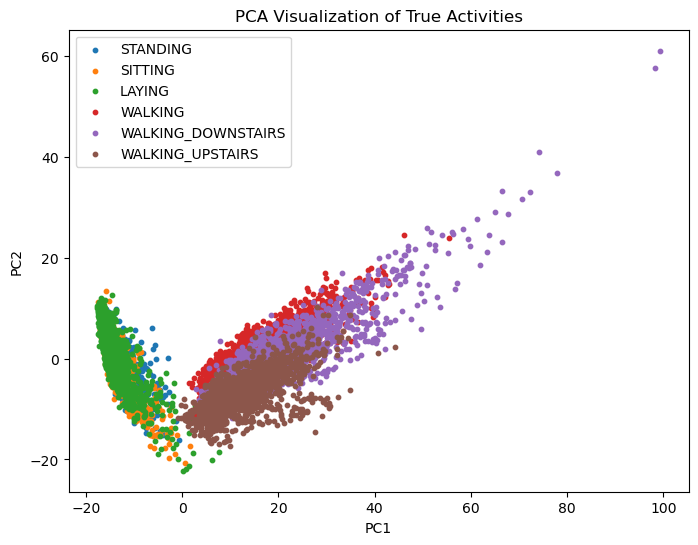

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for activity in y["Activity"].unique():
    idx = y["Activity"] == activity
    plt.scatter(X_pca.loc[idx, "PC1"],
                X_pca.loc[idx, "PC2"],
                label=activity,
                s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of True Activities")
plt.legend()
plt.savefig("PCA Visualization of True Activities")
plt.show()

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [20]:
wcss = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # WCSS (Inertia)
    wcss.append(kmeans.inertia_)

    # Silhouette Score
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

    print(f"k={k}, WCSS={kmeans.inertia_:.2f}, Silhouette={score:.4f}")

k=2, WCSS=3272856.62, Silhouette=0.3937
k=3, WCSS=2921077.60, Silhouette=0.3155
k=4, WCSS=2781602.14, Silhouette=0.1500
k=5, WCSS=2654789.79, Silhouette=0.1286
k=6, WCSS=2577180.43, Silhouette=0.1099
k=7, WCSS=2519774.22, Silhouette=0.0816
k=8, WCSS=2465378.96, Silhouette=0.0749


In [21]:
results_df = pd.DataFrame({
    "k": list(k_values),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

print(results_df)

   k          WCSS  Silhouette Score
0  2  3.272857e+06          0.393732
1  3  2.921078e+06          0.315484
2  4  2.781602e+06          0.150005
3  5  2.654790e+06          0.128631
4  6  2.577180e+06          0.109895
5  7  2.519774e+06          0.081599
6  8  2.465379e+06          0.074867


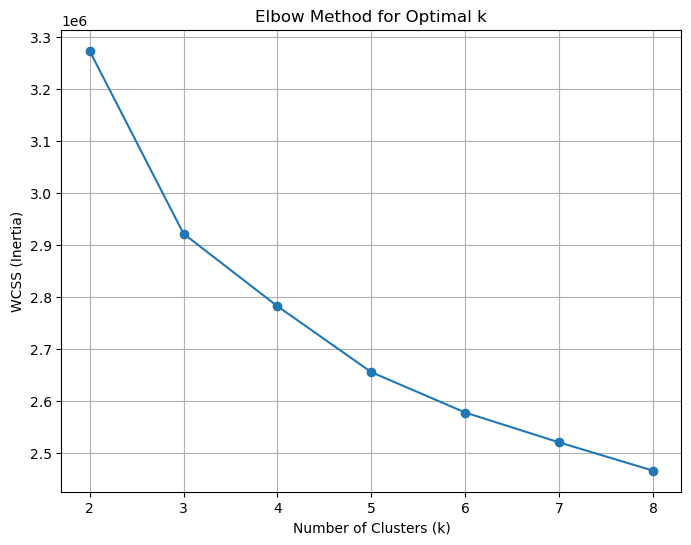

In [22]:
plt.figure(figsize=(8,6))
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid()

plt.savefig("elbow_plot.png")   # ✅ SAVE
plt.show()

In [23]:
best_k = results_df.loc[results_df["Silhouette Score"].idxmax(), "k"]
print("Best k based on Silhouette:", best_k)

Best k based on Silhouette: 2


In [24]:
kmeans_final = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

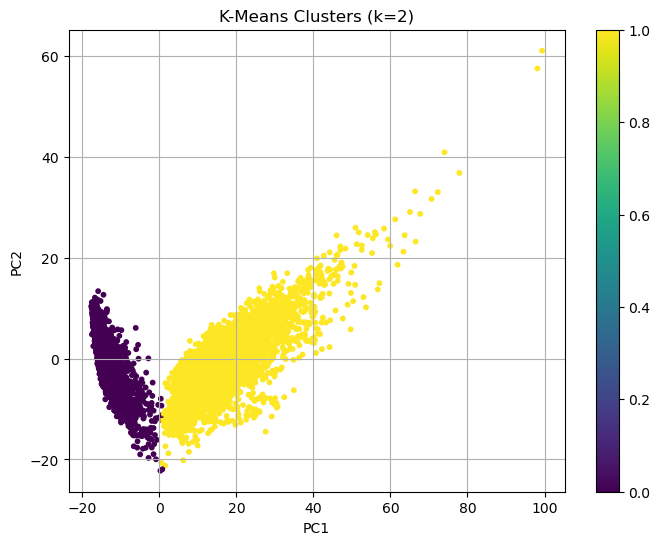

In [25]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(X_pca["PC1"], X_pca["PC2"],
                      c=kmeans_labels, cmap='viridis', s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters (k={best_k})")

plt.colorbar(scatter)
plt.grid()

plt.savefig("kmeans_clusters.png")   # ✅ SAVE
plt.show()

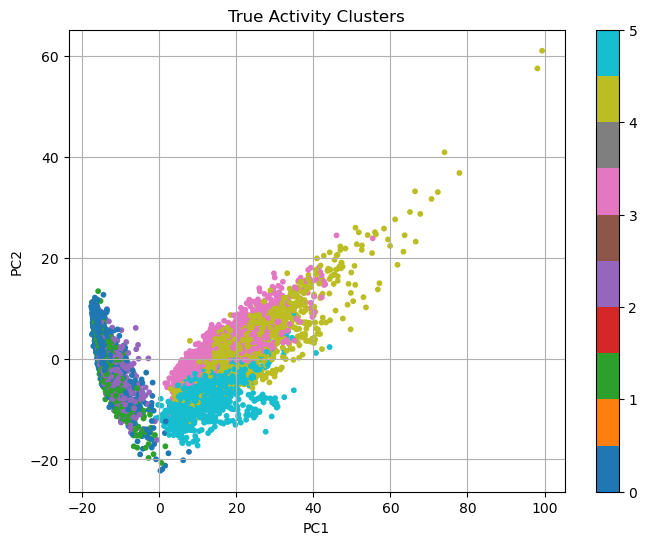

In [26]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(X_pca["PC1"], X_pca["PC2"],
                      c=y["Activity"].astype('category').cat.codes,
                      cmap='tab10', s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("True Activity Clusters")

plt.colorbar(scatter)
plt.grid()

plt.savefig("true_clusters.png")   # ✅ SAVE
plt.show()

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [28]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, 4])

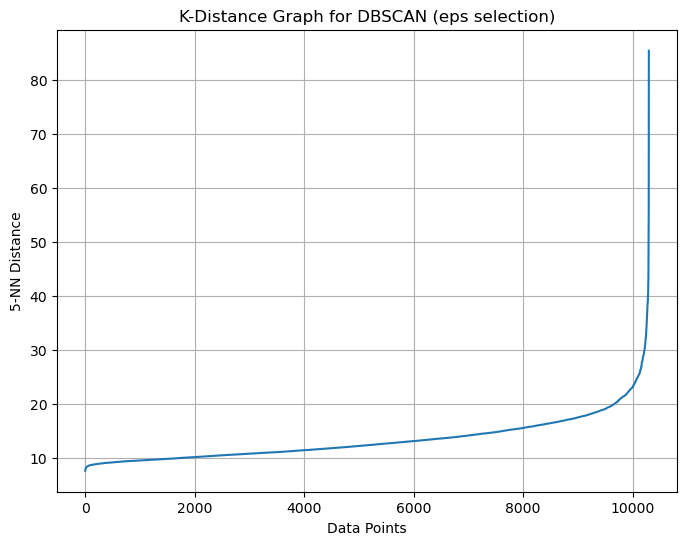

In [29]:
plt.figure(figsize=(8,6))
plt.plot(distances)
plt.xlabel("Data Points")
plt.ylabel("5-NN Distance")
plt.title("K-Distance Graph for DBSCAN (eps selection)")
plt.grid()

plt.savefig("dbscan_k_distance.png")   # ✅ SAVE
plt.show()

In [30]:
eps = 2.0
min_samples = 5

dbscan = DBSCAN(eps=2.0, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

unique_labels = set(db_labels)

print("Unique clusters:", unique_labels)
print("Number of clusters:", len(unique_labels) - (1 if -1 in db_labels else 0))
print("Noise points:", list(db_labels).count(-1))

Unique clusters: {np.int64(-1)}
Number of clusters: 0
Noise points: 10299


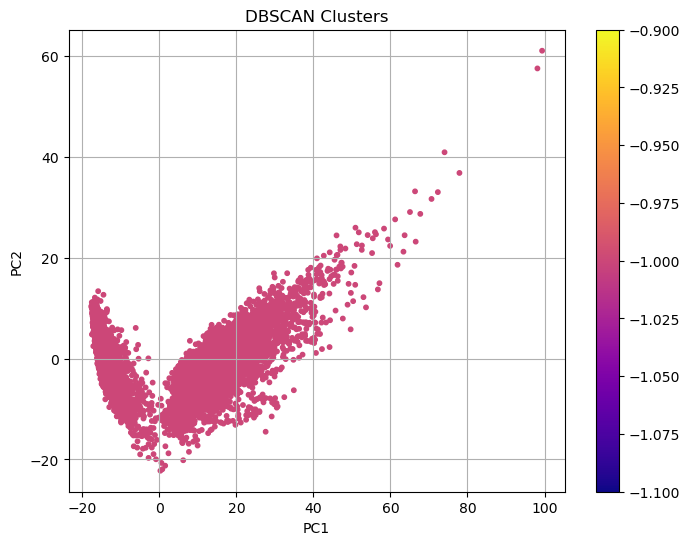

In [31]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(X_pca["PC1"], X_pca["PC2"],
                      c=db_labels, cmap='plasma', s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters")

plt.colorbar(scatter)
plt.grid()

plt.savefig("dbscan_clusters.png")   # ✅ SAVE
plt.show()

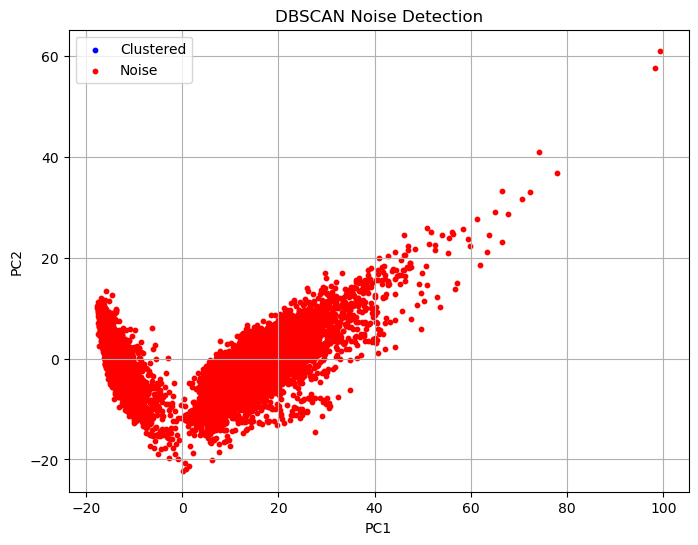

In [32]:
plt.figure(figsize=(8,6))

# Normal points
plt.scatter(X_pca[db_labels != -1]["PC1"],
            X_pca[db_labels != -1]["PC2"],
            c='blue', s=10, label="Clustered")

# Noise points
plt.scatter(X_pca[db_labels == -1]["PC1"],
            X_pca[db_labels == -1]["PC2"],
            c='red', s=10, label="Noise")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Noise Detection")

plt.legend()
plt.grid()

plt.savefig("dbscan_noise.png")   # ✅ SAVE
plt.show()

In [33]:
if len(set(db_labels)) > 1 and -1 not in set(db_labels):
    db_silhouette = silhouette_score(X_scaled, db_labels)
else:
    db_silhouette = "Not valid"

print("DBSCAN Silhouette Score:", db_silhouette)

DBSCAN Silhouette Score: Not valid


In [34]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

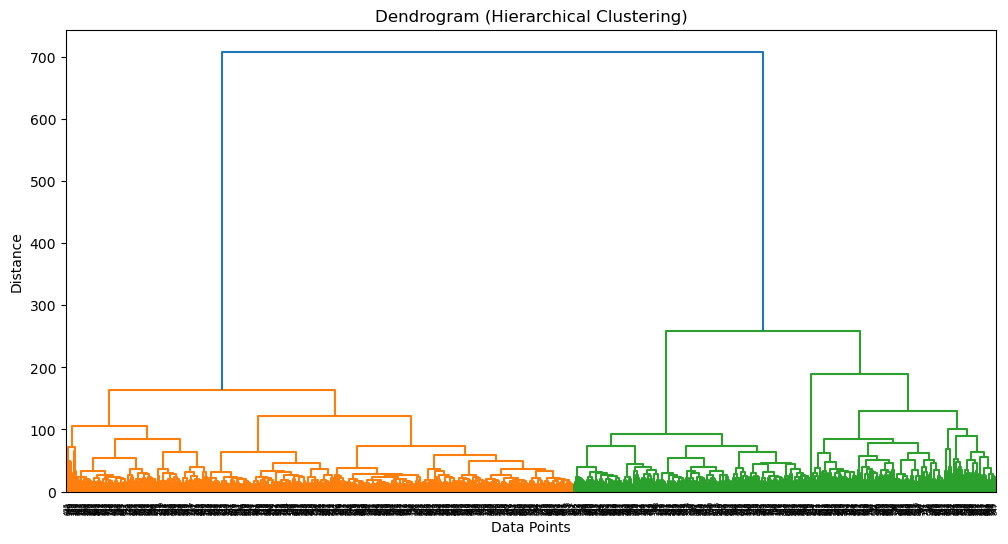

In [36]:
sample_data = X_scaled.sample(n=1000, random_state=42)

plt.figure(figsize=(12,6))

sch.dendrogram(
    sch.linkage(sample_data, method='ward')
)

plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.savefig("dendrogram.png")   # ✅ SAVE
plt.show()

In [37]:
k_hc = int(best_k) 
hc = AgglomerativeClustering(n_clusters=k_hc, linkage='ward')

hc_labels = hc.fit_predict(X_scaled)

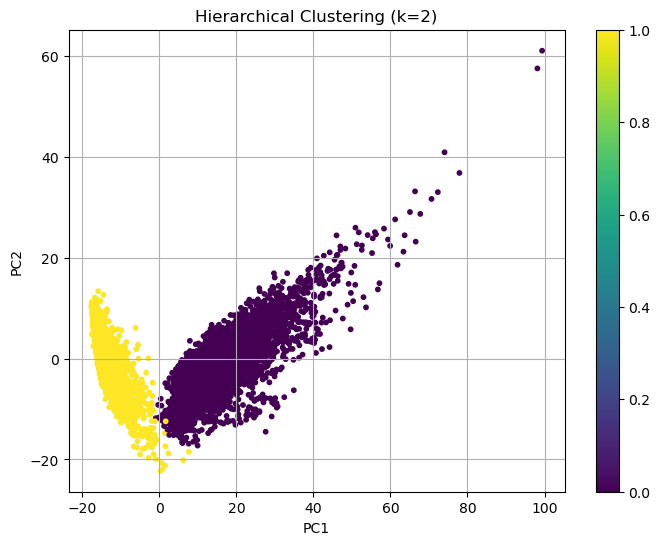

In [38]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(X_pca["PC1"], X_pca["PC2"],
                      c=hc_labels, cmap='viridis', s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Clustering (k={k_hc})")

plt.colorbar(scatter)
plt.grid()

plt.savefig("hierarchical_clusters.png")   # ✅ SAVE
plt.show()

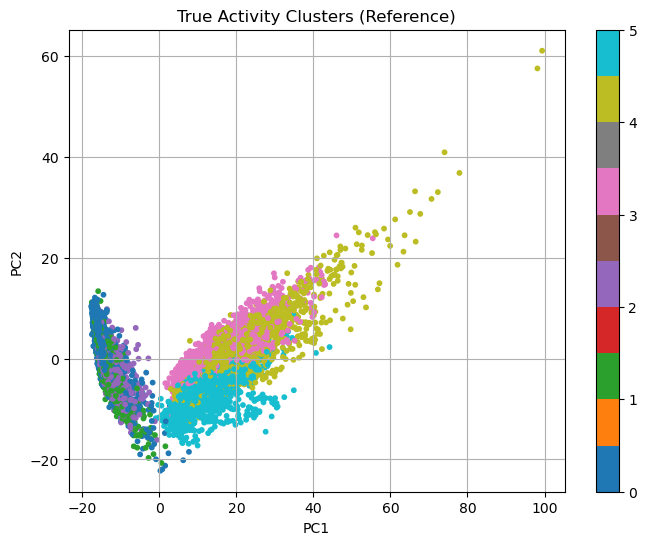

In [39]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(X_pca["PC1"], X_pca["PC2"],
                      c=y["Activity"].astype('category').cat.codes,
                      cmap='tab10', s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("True Activity Clusters (Reference)")

plt.colorbar(scatter)
plt.grid()

plt.savefig("true_clusters_hc.png")   # ✅ SAVE
plt.show()

In [40]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)


In [41]:
true_labels = y["Activity"].astype('category').cat.codes

def evaluate_clustering(X, labels, true_labels, name="Model"):
    results = {}

    # Internal Metrics
    if len(set(labels)) > 1 and -1 not in set(labels):
        results["Silhouette"] = silhouette_score(X, labels)
        results["Davies-Bouldin"] = davies_bouldin_score(X, labels)
        results["Calinski-Harabasz"] = calinski_harabasz_score(X, labels)
    else:
        results["Silhouette"] = None
        results["Davies-Bouldin"] = None
        results["Calinski-Harabasz"] = None

    # External Metrics
    results["ARI"] = adjusted_rand_score(true_labels, labels)
    results["NMI"] = normalized_mutual_info_score(true_labels, labels)

    return results

In [42]:
kmeans_results = evaluate_clustering(X_scaled, kmeans_labels, true_labels, "KMeans")
dbscan_results = evaluate_clustering(X_scaled, db_labels, true_labels, "DBSCAN")
hc_results = evaluate_clustering(X_scaled, hc_labels, true_labels, "Hierarchical")

In [43]:
results_table = pd.DataFrame([
    kmeans_results,
    dbscan_results,
    hc_results
], index=["K-Means", "DBSCAN", "Hierarchical"])

print(results_table)

              Silhouette  Davies-Bouldin  Calinski-Harabasz       ARI  \
K-Means         0.393732        1.070744        7880.813904  0.329611   
DBSCAN               NaN             NaN                NaN  0.000000   
Hierarchical    0.393374        1.071694        7859.755364  0.332532   

                   NMI  
K-Means       0.545464  
DBSCAN        0.000000  
Hierarchical  0.556789  


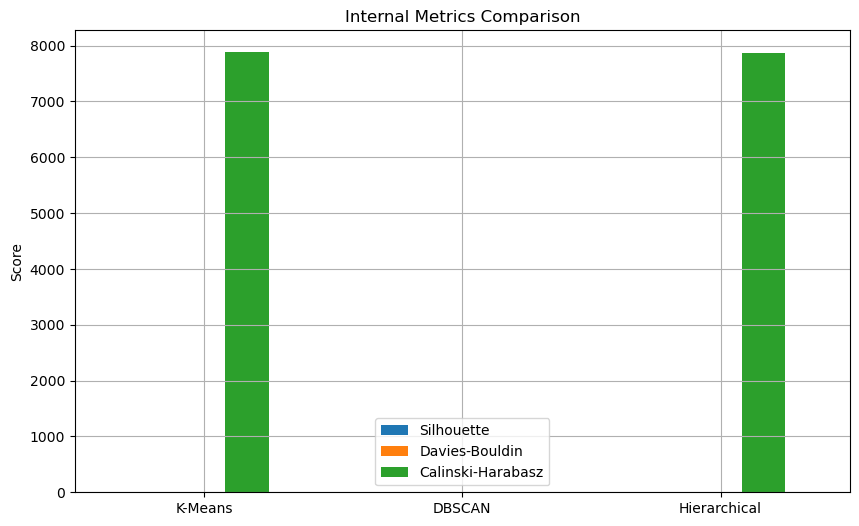

In [44]:
results_table[["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]].plot(kind='bar', figsize=(10,6))

plt.title("Internal Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()

plt.savefig("internal_metrics.png")   # ✅ SAVE
plt.show()

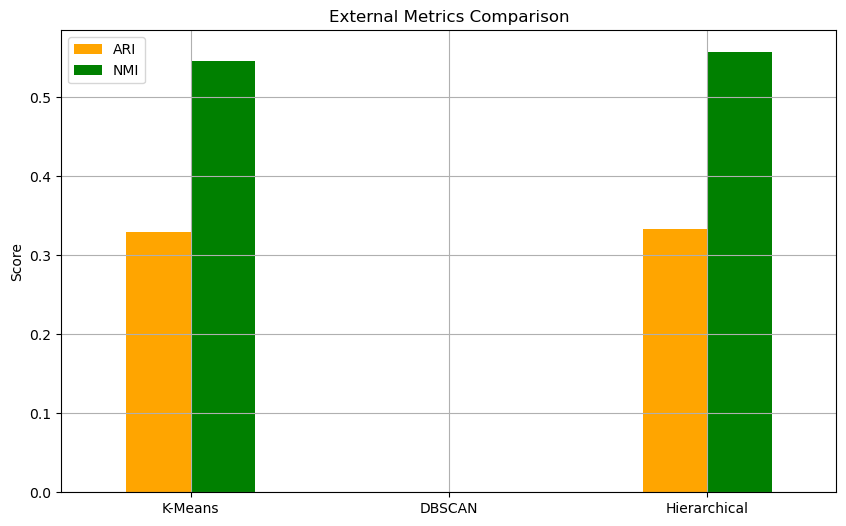

In [45]:
results_table[["ARI", "NMI"]].plot(kind='bar', figsize=(10,6), color=['orange','green'])

plt.title("External Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()

plt.savefig("external_metrics.png")   # ✅ SAVE
plt.show()

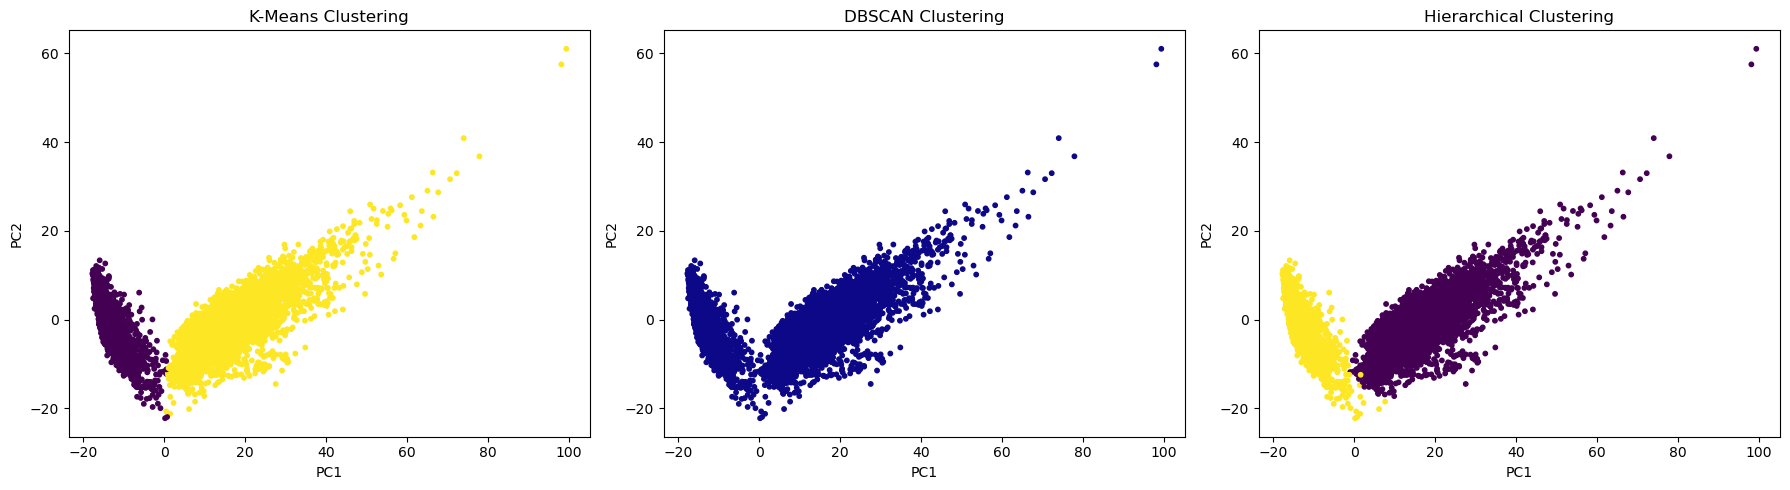

In [46]:
plt.figure(figsize=(18,5))

# K-Means
plt.subplot(1,3,1)
plt.scatter(X_pca["PC1"], X_pca["PC2"], c=kmeans_labels, cmap='viridis', s=10)
plt.title("K-Means Clustering")
plt.xlabel("PC1"); plt.ylabel("PC2")

# DBSCAN
plt.subplot(1,3,2)
plt.scatter(X_pca["PC1"], X_pca["PC2"], c=db_labels, cmap='plasma', s=10)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1"); plt.ylabel("PC2")

# Hierarchical
plt.subplot(1,3,3)
plt.scatter(X_pca["PC1"], X_pca["PC2"], c=hc_labels, cmap='viridis', s=10)
plt.title("Hierarchical Clustering")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.tight_layout()

plt.savefig("all_clusters_comparison.png")   # ✅ SAVE
plt.show()

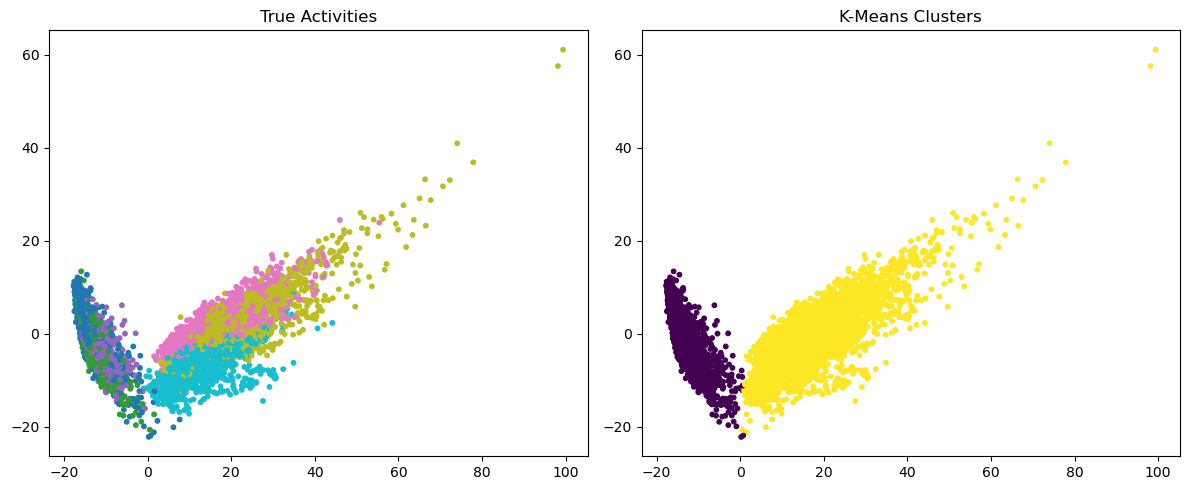

In [47]:
plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
plt.scatter(X_pca["PC1"], X_pca["PC2"],
            c=true_labels, cmap='tab10', s=10)
plt.title("True Activities")

# K-Means (best baseline)
plt.subplot(1,2,2)
plt.scatter(X_pca["PC1"], X_pca["PC2"],
            c=kmeans_labels, cmap='viridis', s=10)
plt.title("K-Means Clusters")

plt.tight_layout()

plt.savefig("true_vs_kmeans.png")   # ✅ SAVE
plt.show()